In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from itertools import combinations
!pip install xgboost
from xgboost import XGBClassifier
from torch import nn
import torch
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
RANDOM_SEED = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 43.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# load the data from the exploratory notebook
flight_data = pd.read_csv('cleaned_flight_data.csv')

/tmp/ipykernel_53/2240060020.py:2: DtypeWarning: Columns (11,13) have mixed types. Specify dtype option on import or set low_memory=False.
  flight_data = pd.read_csv('cleaned_flight_data.csv')


In [3]:
# most relevant columns obtained through feature evaluation
data = flight_data[['DepDel15','CRSElapsedTime','DistanceGroup','sched_dep_sin', 'sched_dep_cos',
                      'origin_temp','origin_prcp','origin_dwpt',]]

data= data.dropna()

# Logistic Regression

In [4]:
y = data['DepDel15']
x = data.drop('DepDel15', axis=1)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# create baseline model with relevant columns and no parameter tuning
model = LogisticRegression(random_state=RANDOM_SEED)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
acc = accuracy_score(y_test,y_pred)

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Baseline F1 Score: {f1_score(y_test, y_pred)}")
print(f"Baseline Recall Score: {recall_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Baseline Accuracy: 0.7075055187637969
Baseline F1 Score: 0.1286989196806012
Baseline Recall Score: 0.07314468766684463
Baseline ROC-AUC: 0.5232584033545681
              precision    recall  f1-score   support

         0.0       0.71      0.97      0.82      4469
         1.0       0.54      0.07      0.13      1873

    accuracy                           0.71      6342
   macro avg       0.62      0.52      0.48      6342
weighted avg       0.66      0.71      0.62      6342



While the baseline accuracy is respectable, the baseline recall is quite miserable\. Model enhancement must be increased to improve recall\.

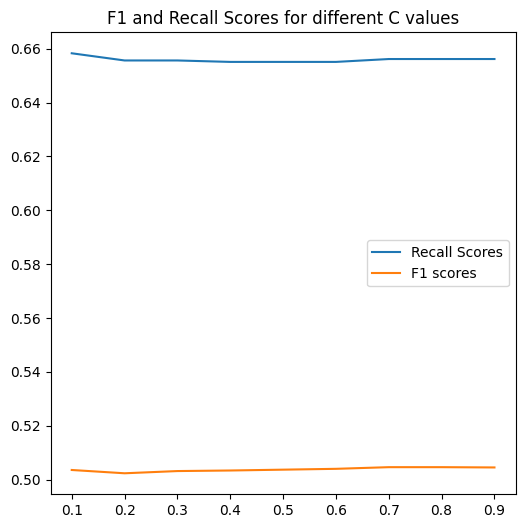

In [5]:
# identify best c to use in model
cs = np.arange(0.1, 1.0, 0.1)

scores = []

for c in cs:
    model = LogisticRegression(max_iter = 1000, class_weight='balanced',random_state=RANDOM_SEED, penalty='l1', solver='liblinear', C=c)
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    rec = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    scores.append((c, rec, f1))
scores = pd.DataFrame(scores)
plt.figure(figsize=(6,6))
plt.plot(scores[0], scores[1], label='Recall Scores')
plt.plot(scores[0], scores[2], label='F1 scores')
plt.title("F1 and Recall Scores for different C values")
plt.legend()
plt.show()

In [34]:
# better tuned model with higher recall

log_res_model = LogisticRegression(max_iter = 1000, class_weight='balanced',random_state=RANDOM_SEED, penalty='l1',solver='liblinear', C=0.1)
log_res_model.fit(x_train_scaled, y_train)
y_pred = log_res_model.predict(x_test_scaled)
acc = accuracy_score(y_test,y_pred)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")
print(f"Recall Score: {recall_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.6147686832740213
F1 Score: 0.6267241379310345
Recall Score: 0.646797153024911
              precision    recall  f1-score   support

         0.0       0.62      0.58      0.60      2248
         1.0       0.61      0.65      0.63      2248

    accuracy                           0.61      4496
   macro avg       0.62      0.61      0.61      4496
weighted avg       0.62      0.61      0.61      4496



The highest recall from the baseline model was 0\.09\. By adding in parameters, the recall and F1 scores were able to increase drastically, producing a recall of 0\.66\.

Lasso regression is utilized with the L1 penalty to minimize coefficients so that all variables can be scaled and evaluated similarly\.

Due to the volume of flights, the percentage of flights that were delayed are much less than flights that actually take off on time\. 

In [7]:
y_probs = log_res_model.predict_proba(x_test)[:, 1]
lower_threshold = 0.45
y_pred_high_recall = (y_probs >= lower_threshold).astype(int)
print(classification_report(y_test,y_pred_high_recall))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      4469
         1.0       0.30      1.00      0.46      1873

    accuracy                           0.30      6342
   macro avg       0.15      0.50      0.23      6342
weighted avg       0.09      0.30      0.13      6342

/root/venv/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted s

Investigation into lowering the threshold for classifying predictions does not prove beneficial in this sense\. Obtaining a recall score of 0\.64 and F1 of 0\.49 is much more respectable than a recall of 0\.09\. By lowering the threshold to 0\.45, the recall improved to 1 and the precision dropped to 0, therefore making it a much more inaccurate model\. The threshold will remain at 0\.5\.

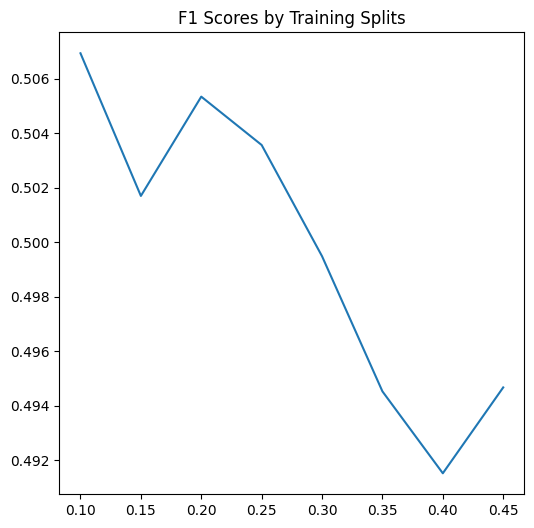

In [8]:
y = data['DepDel15']
x = data.drop('DepDel15', axis=1)

sizes = np.arange(0.1, 0.5, 0.05)
splits = []
for size in sizes:
    temp_x_train, temp_x_test, temp_y_train, temp_y_test = train_test_split(
        x, y, test_size=size, random_state=42, stratify=y)

    scaler = StandardScaler()
    temp_x_train_scaled = scaler.fit_transform(temp_x_train)
    temp_x_test_scaled = scaler.transform(temp_x_test)
    temp_res_model = LogisticRegression(max_iter = 1000, class_weight='balanced',random_state=RANDOM_SEED, penalty='l1',solver='liblinear', C=0.1)
    temp_res_model.fit(temp_x_train_scaled, temp_y_train)
    y_pred = temp_res_model.predict(temp_x_test_scaled)
    f1 = f1_score(temp_y_test, y_pred)
    splits.append((size, f1))
plt.figure(figsize=(6,6))
a,b = zip(*splits)
plt.title("F1 Scores by Training Splits")
plt.plot(a,b)
plt.show()

In [9]:
# look at coefficient weights
#['CRSElapsedTime','DistanceGroup','sched_dep_sin','sched_dep_cos', 'origin_temp','origin_prcp','origin_dwpt']
log_res_model.coef_

array([[ 0.18637751, -0.20101459, -0.28816575,  0.14443922, -0.96033648,
         0.08758473,  0.55874946]])

Based on feature investigation, origin dewpoint appears to have the biggest positive impact on determining if a flight is delayed or not\. The origin temperature has the biggest negative impact on a flight getting delayed\. The training split of 0\.20 produced the highest F1 score\.

In [32]:
final_logistic_regression_model = LogisticRegression(max_iter = 1000, class_weight='balanced',random_state=RANDOM_SEED, penalty='l1',solver='liblinear', C=0.1)
final_logistic_regression_model.fit(x_train_scaled, y_train)
y_pred = final_logistic_regression_model.predict(x_test_scaled)
acc = accuracy_score(y_test,y_pred)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")
print(f"Recall Score: {recall_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))


Accuracy: 0.6147686832740213
F1 Score: 0.6267241379310345
Recall Score: 0.646797153024911
              precision    recall  f1-score   support

         0.0       0.62      0.58      0.60      2248
         1.0       0.61      0.65      0.63      2248

    accuracy                           0.61      4496
   macro avg       0.62      0.61      0.61      4496
weighted avg       0.62      0.61      0.61      4496



In [11]:
# looking at what classifications were wrong
indices = np.where(y_test != y_pred)[0]
indices
subset = data.iloc[indices]
mislabeled_delays = subset[subset['DepDel15'] == 1]
mislabeled_delays

,DepDel15,CRSElapsedTime,DistanceGroup,sched_dep_sin,sched_dep_cos,origin_temp,origin_prcp,origin_dwpt
5,1.0,76.0,1,-0.831470,0.555570,13.0,0.0,9.1
12,1.0,90.0,1,0.652760,-0.757565,6.0,0.0,2.1
13,1.0,93.0,2,-0.906308,0.422618,13.0,0.0,9.1
17,1.0,68.0,1,-0.321439,-0.946930,1.0,0.0,0.0
35,1.0,121.0,3,-0.915311,-0.402747,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
6496,1.0,98.0,2,-0.704015,0.710185,-4.0,0.0,-12.9
6498,1.0,98.0,2,-0.704015,0.710185,-8.0,0.0,-15.2
6499,1.0,98.0,2,-0.704015,0.710185,-15.0,0.0,-22.0
6502,1.0,98.0,2,-0.704015,0.710185,-6.0,0.0,-16.9


In [12]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
log_reg_scores = cross_val_score(final_logistic_regression_model, x_scaled, y, cv=cv, scoring='f1')
print("Logistic Regression Metrics - 5 CV")
print(f"F1 Mean: {log_reg_scores.mean()}")
print(f"F1 STD: {log_reg_scores.std()}\n")

log_reg_scores2 = cross_val_score(final_logistic_regression_model, x_scaled, y, cv=cv, scoring='precision')
print(f"Precision Mean: {log_reg_scores2.mean()}")
print(f"Precision STD: {log_reg_scores2.std()}\n")

log_reg_scores3 = cross_val_score(final_logistic_regression_model, x_scaled, y, cv=cv, scoring='accuracy')
print(f"Accuracy Mean: {log_reg_scores3.mean()}")
print(f"Accuracy STD: {log_reg_scores3.std()}\n")

log_reg_scores3 = cross_val_score(final_logistic_regression_model, x_scaled, y, cv=cv, scoring='recall')
print(f"Recall Mean: {log_reg_scores3.mean()}")
print(f"Recall STD: {log_reg_scores3.std()}")

Logistic Regression Metrics - 5 CV
F1 Mean: 0.4937369788499722
F1 STD: 0.008397926797670702

Precision Mean: 0.39935370849542917
Precision STD: 0.007210427425442884

Accuracy Mean: 0.6082791247782378
Accuracy STD: 0.007301927476626972

Recall Mean: 0.6466034766390767
Recall STD: 0.011712657739934306


# XGBoost

In [13]:
data = flight_data[['DepDel15','CRSElapsedTime','DistanceGroup','sched_dep_sin', 'sched_dep_cos',
                      'origin_temp','origin_prcp','origin_dwpt',]]

data= data.dropna()
y = data['DepDel15']
x = data.drop('DepDel15', axis=1)
x_train,x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [14]:
# baseline model measurement
model = XGBClassifier()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test)
clasifs = classification_report(y_test, y_pred)
print(clasifs)

              precision    recall  f1-score   support

         0.0       0.73      0.47      0.57      5362
         1.0       0.32      0.60      0.42      2248

    accuracy                           0.51      7610
   macro avg       0.53      0.53      0.49      7610
weighted avg       0.61      0.51      0.53      7610



The baseline model for XGB produces an accuracy of 0\.63 and recall of 0\.14, already better than the baseline for logistic regression\. Model enhancement will be conducted, with the same predictors as seen in the logistic regression for direct comparison\.

Note: scale\_pos\_weight works best when it is a fraction of the two different classes, so that is what will be utilized in cells below\. 

In initial iterations of this model training, the precision, recall, F1, and accuracy scores were a bit lower than expected\. By lowering the classification threshold from 0\.5 to 0\.45, the numbers jumped drastically, as unseen in the logistic regression model\. All models will use a threshold of 0\.45 below\.

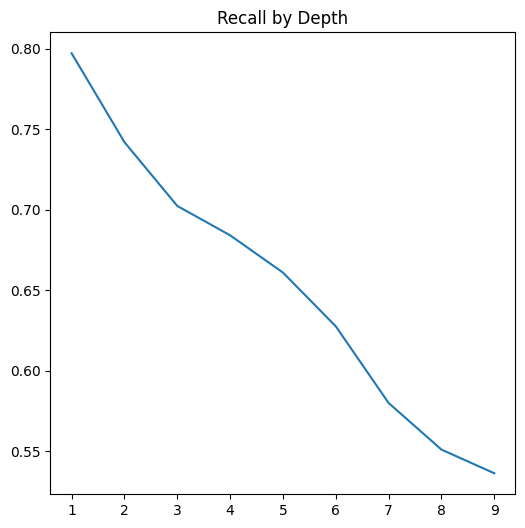

In [15]:
# testing different depths
depths = np.arange(1,10,1)
plotter = []
for depth in depths:
    model = XGBClassifier(random_state=RANDOM_SEED, scale_pos_weight=(2747/1171), 
                            eval_metric='logloss', max_depth=depth,
                            n_estimators=150, subsample=0.8)
    model.fit(x_train_scaled, y_train)
    y_probs = model.predict_proba(x_test_scaled)[:, 1]
    lower_threshold = 0.45
    y_pred_high_recall = (y_probs >= lower_threshold).astype(int)
    plotter.append((depth, recall_score(y_test,y_pred_high_recall)))
    #rec = classification_report(y_test, y_pred_high_recall)
    #print(rec)
a,b = zip(*plotter)
plt.figure(figsize=(6,6))
plt.plot(a,b)
plt.title("Recall by Depth")
plt.show()

While a depth of 1 produces the best recall, that is usually a sign of underfitting\. The depth of 4 seems to produce one with the least diminishing returns, so that one will be used\. 

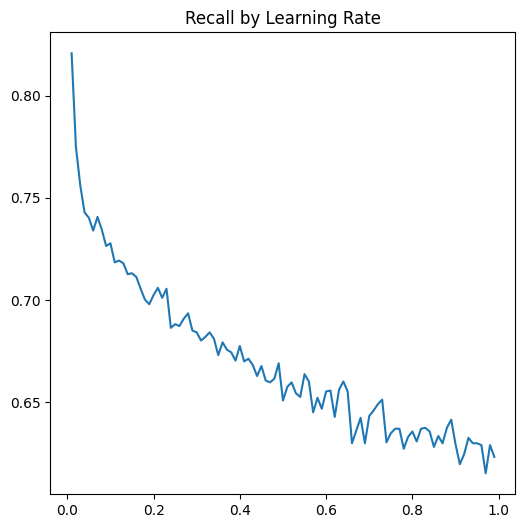

In [16]:
# testing different learning rates
rates = np.arange(0.01,1,0.01)
plotter = []
for rate in rates:
    model = XGBClassifier(random_state=RANDOM_SEED, scale_pos_weight=(2747/1171), 
                            eval_metric='logloss', max_depth=4, learning_rate=rate,
                            n_estimators=150, subsample=0.8)
    model.fit(x_train_scaled, y_train)
    y_probs = model.predict_proba(x_test_scaled)[:, 1]
    lower_threshold = 0.45
    y_pred_high_recall = (y_probs >= lower_threshold).astype(int)
    plotter.append((rate, recall_score(y_test,y_pred_high_recall)))
    #rec = classification_report(y_test, y_pred_high_recall)
    #print(rec)
a,b = zip(*plotter)
plt.figure(figsize=(6,6))
plt.plot(a,b)
plt.title("Recall by Learning Rate")
plt.show()

Recall decreases after 0\.05, so that is the learning rate that will be utilized\.

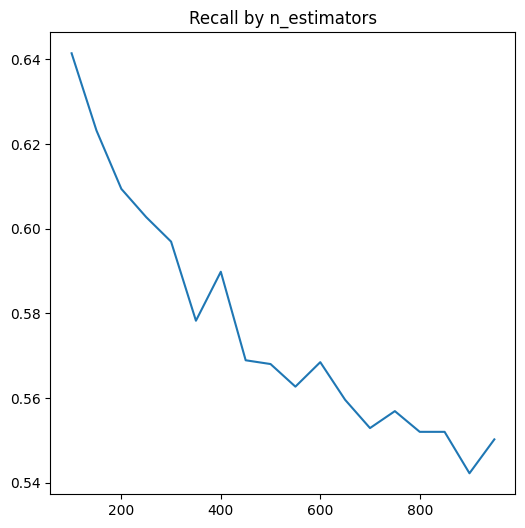

In [17]:
# testing different n_estimators
nests = np.arange(100,1000,50)
plotter = []
for nest in nests:
    model = XGBClassifier(random_state=RANDOM_SEED, scale_pos_weight=(2747/1171), 
                            eval_metric='logloss', max_depth=4, learning_rate=rate,
                            n_estimators=nest, subsample=0.8)
    model.fit(x_train_scaled, y_train)
    y_probs = model.predict_proba(x_test_scaled)[:, 1]
    lower_threshold = 0.45
    y_pred_high_recall = (y_probs >= lower_threshold).astype(int)
    plotter.append((nest, recall_score(y_test,y_pred_high_recall)))
    #rec = classification_report(y_test, y_pred_high_recall)
    #print(rec)
a,b = zip(*plotter)
plt.figure(figsize=(6,6))
plt.plot(a,b)
plt.title("Recall by n_estimators")
plt.show()

Highly regarded as the minimum number of n\_estimators for accurate algorithm learning, 100 n\_estimators will be used\.

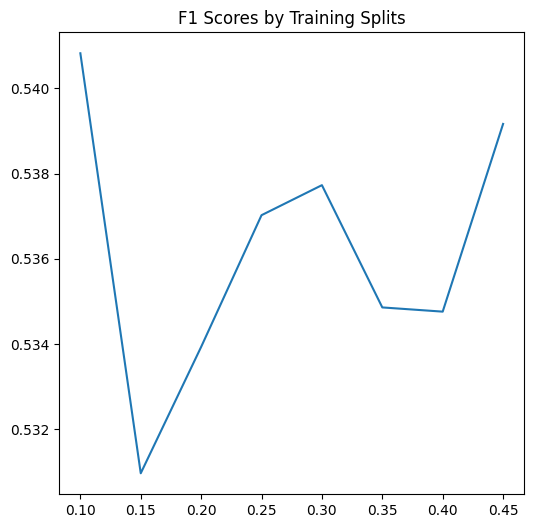

In [18]:
sizes = np.arange(0.1, 0.5, 0.05)
splits = []
for size in sizes:
    temp_x_train, temp_x_test, temp_y_train, temp_y_test = train_test_split(
        x, y, test_size=size, random_state=42, stratify=y)

    scaler = StandardScaler()
    temp_x_train_scaled = scaler.fit_transform(temp_x_train)
    temp_x_test_scaled = scaler.transform(temp_x_test)
    temp_xg_model = xg_model = XGBClassifier(random_state=RANDOM_SEED, scale_pos_weight=(2747/1171), 
                        eval_metric='logloss', max_depth=4, learning_rate=0.05,
                        n_estimators=100, subsample=0.8)
    temp_xg_model.fit(temp_x_train_scaled, temp_y_train)
    y_pred = temp_xg_model.predict(temp_x_test_scaled)
    f1 = f1_score(temp_y_test, y_pred)
    splits.append((size, f1))
plt.figure(figsize=(6,6))
a,b = zip(*splits)
plt.title("F1 Scores by Training Splits")
plt.plot(a,b)
plt.show()

In [19]:
# combining parameters for final model
data = flight_data[['DepDel15','CRSElapsedTime','DistanceGroup','sched_dep_sin', 'sched_dep_cos',
                      'origin_temp','origin_prcp','origin_dwpt',]]

data= data.dropna()
y = data['DepDel15']
x = data.drop('DepDel15', axis=1)
x_train,x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
xg_model = XGBClassifier(random_state=RANDOM_SEED, scale_pos_weight=(2747/1171), 
                        eval_metric='logloss', max_depth=4, learning_rate=0.05,
                        n_estimators=100, subsample=0.8)
xg_model.fit(x_train_scaled, y_train)
y_probs = xg_model.predict_proba(x_test_scaled)[:, 1]
lower_threshold = 0.45
y_pred_high_recall = (y_probs >= lower_threshold).astype(int)
rec = classification_report(y_test, y_pred_high_recall)
print(rec)

              precision    recall  f1-score   support

         0.0       0.85      0.56      0.67      5362
         1.0       0.42      0.76      0.54      2248

    accuracy                           0.62      7610
   macro avg       0.63      0.66      0.61      7610
weighted avg       0.72      0.62      0.63      7610



In [20]:
# looking at what classifications were wrong
indices = np.where(y_test != y_pred_high_recall)[0]
indices
subset = data.iloc[indices]
mislabeled_delays = subset[subset['DepDel15'] == 1]
mislabeled_delays

,DepDel15,CRSElapsedTime,DistanceGroup,sched_dep_sin,sched_dep_cos,origin_temp,origin_prcp,origin_dwpt
0,1.0,120.0,3,-3.502074e-01,-0.936672,8.0,0.0,2.0
1,1.0,76.0,1,-8.314696e-01,0.555570,13.0,0.0,9.1
12,1.0,90.0,1,6.527598e-01,-0.757565,6.0,0.0,2.1
13,1.0,93.0,2,-9.063078e-01,0.422618,13.0,0.0,9.1
33,1.0,72.0,1,-4.809888e-01,-0.876727,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
7804,1.0,61.0,1,1.224647e-16,-1.000000,-6.0,0.0,-16.0
7805,1.0,69.0,1,-9.537170e-01,-0.300706,-6.0,0.0,-15.0
7806,1.0,61.0,1,-6.788007e-01,0.734323,-3.0,0.0,-14.7
7808,1.0,80.0,1,8.968727e-01,-0.442289,-7.0,0.0,-15.9


In [21]:
# look at most important predictors in the model
xg_model.feature_importances_

array([0.05118444, 0.06092392, 0.18132491, 0.1084414 , 0.2464381 ,
       0.20108137, 0.15060595], dtype=float32)

In [22]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
xgboost_scores = cross_val_score(xg_model, x_scaled, y, cv=cv, scoring='f1')
print("XGBoost Metrics - 5 CV")
print(f"F1 Mean: {xgboost_scores.mean()}")
print(f"F1 STD: {xgboost_scores.std()}\n")

xgboost_scores2 = cross_val_score(xg_model, x_scaled, y, cv=cv, scoring='precision')
print(f"Precision Mean: {xgboost_scores2.mean()}")
print(f"Precision STD: {xgboost_scores2.std()}\n")

xgboost_scores3 = cross_val_score(xg_model, x_scaled, y, cv=cv, scoring='accuracy')
print(f"Accuracy Mean: {xgboost_scores3.mean()}")
print(f"Accuracy STD: {xgboost_scores3.std()}\n")

xgboost_scores3 = cross_val_score(xg_model, x_scaled, y, cv=cv, scoring='recall')
print(f"Recall Mean: {xgboost_scores3.mean()}")
print(f"Recall STD: {xgboost_scores3.std()}")

XGBoost Metrics - 5 CV
F1 Mean: 0.5400407527243077
F1 STD: 0.0035519456047397695

Precision Mean: 0.44158109692580066
Precision STD: 0.004329088223442675

Accuracy Mean: 0.650187265917603
Accuracy STD: 0.004950235889013229

Recall Mean: 0.6951796970120714
Recall STD: 0.00995144678549139


In [30]:
# sensitivity testing with origin_snow removed on balanced data
data = flight_data[['DepDel15','CRSElapsedTime','DistanceGroup','sched_dep_sin', 'sched_dep_cos',
                      'origin_temp','origin_prcp','origin_dwpt']]

data= data.dropna()
# split the data into the two groups, then take all the delayed flights and same num of non-delayed
class_0 = data[data['DepDel15'] == 0]
class_1 = data[data['DepDel15'] == 1]
size = min(len(class_0), len(class_1))

balanced_data = pd.concat([class_0.sample(size, random_state=RANDOM_SEED), class_1.sample(size, random_state=RANDOM_SEED)])

# shuffle the data to ensure randomness
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

# rerun the optimized model with the new split data
y = balanced_data['DepDel15']
x = balanced_data.drop('DepDel15', axis=1)
# scale_pos_weight=(2747/1171)
x_train,x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
# remove the scale_pos_weight, as the balanced data is evenly split now
xg_model = XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', max_depth=4, learning_rate=0.05,n_estimators=100, subsample=0.8)
xg_model.fit(x_train_scaled, y_train)
y_probs = xg_model.predict_proba(x_test_scaled)[:, 1]
lower_threshold = 0.45
y_pred_high_recall = (y_probs >= lower_threshold).astype(int)
rec = classification_report(y_test, y_pred_high_recall)
print(rec)

              precision    recall  f1-score   support

         0.0       0.69      0.52      0.59      2248
         1.0       0.62      0.76      0.68      2248

    accuracy                           0.64      4496
   macro avg       0.65      0.64      0.64      4496
weighted avg       0.65      0.64      0.64      4496



In [24]:
# cross validation of balanced data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
xbal_scores = cross_val_score(xg_model, x_scaled, y, cv=cv, scoring='f1')
print("XGBoost (Balanced Data) Metrics - 5 CV")
print(f"F1 Mean: {xbal_scores.mean()}")
print(f"F1 STD: {xbal_scores.std()}\n")

xbal_scores2 = cross_val_score(xg_model, x_scaled, y, cv=cv, scoring='precision')
print(f"Precision Mean: {xbal_scores2.mean()}")
print(f"Precision STD: {xbal_scores2.std()}\n")

xbal_scores3 = cross_val_score(xg_model, x_scaled, y, cv=cv, scoring='accuracy')
print(f"Accuracy Mean: {xbal_scores3.mean()}")
print(f"Accuracy STD: {xbal_scores3.std()}\n")

xbal_scores3 = cross_val_score(xg_model, x_scaled, y, cv=cv, scoring='recall')
print(f"Recall Mean: {xbal_scores3.mean()}")
print(f"Recall STD: {xbal_scores3.std()}")

XGBoost (Balanced Data) Metrics - 5 CV
F1 Mean: 0.688079520108728
F1 STD: 0.0013798886106229013

Precision Mean: 0.5454396750831781
Precision STD: 0.001581312238799171

Accuracy Mean: 0.577605535266198
Accuracy STD: 0.0020379343072218187

Recall Mean: 0.9318050930259693
Recall STD: 0.007441626993946624


# Neural Network

In [25]:
import torch
from torch import nn
import torch.optim as optim
import time
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, TensorDataset,DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import copy
torch.set_num_threads(4)
torch.set_num_interop_threads(4)

In [59]:
data = flight_data[['DepDel15','CRSElapsedTime','DistanceGroup','sched_dep_sin', 
                     'sched_dep_cos', 'origin_temp','origin_prcp','origin_dwpt', 'origin_snow']]

data= data.fillna(0)

y = data['DepDel15'].values.reshape(-1,1)
x = data.drop('DepDel15', axis=1).values

In [61]:
# create train, val, and test loaders of the data
# 60/20/20 split
x_temp, x_test, y_temp, y_test = train_test_split(x,y,test_size=0.2)
x_train, x_val, y_train, y_val = train_test_split(x_temp,y_temp,test_size=0.25) 

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

# convert the data to tensors for nn
train_loader = DataLoader(TensorDataset(torch.FloatTensor(x_train), torch.FloatTensor(y_train)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(x_val), torch.FloatTensor(y_val)), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(x_test), torch.FloatTensor(y_test)), batch_size=32, shuffle=False)

In [28]:
# initial structure construction
class MLP(nn.Module):
    def __init__(self,num_inputs=8,num_outputs=1,num_hiddens=64):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_features = num_inputs, out_features = num_hiddens)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(in_features = num_hiddens, out_features = num_hiddens//2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(in_features = num_hiddens//2, out_features = num_outputs)
    def forward(self, X):
        X = X.flatten(1)
        X = self.fc1(X)
        X = self.relu1(X)
        X = self.fc2(X)
        X = self.relu2(X)
        X = self.fc3(X)
        return X

In [29]:
# model evaluation function
def eval_model(model,data_loader,device,threshold=0.5):
    y_true_list=[]
    y_pred_list=[]
    y_proba = []
    model.eval()
    with torch.no_grad():
        for x,y in data_loader:
            x,y = x.to(device), y.to(device)
            outputs=model(x)
            probs = torch.sigmoid(outputs).squeeze()
            y_pred = (probs >= threshold).long()          
            y_pred_list.extend(y_pred.cpu())
            y_true_list.extend(y.cpu().numpy())
            y_proba.extend(probs.cpu().detach().numpy())
    f1 = f1_score(y_true_list, y_pred_list)
    recall = recall_score(y_true_list,y_pred_list)
    precision = precision_score(y_true_list,y_pred_list)
    report = classification_report(y_true_list,y_pred_list)
    return f1, report, recall, precision, y_true_list, y_pred_list, y_proba

In [53]:
num_inputs = 8
num_outputs = 1
batch_size = 32
hiddens = [32, 64, 128]
lrs = [0.0001, 0.001, 0.01]
batch_size = 32

random_seed = RANDOM_SEED
torch.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
start_time=time.time()
current_best=0.0
best_model=None
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# add in ratio of different classifications
pos_weight = torch.tensor([5362/2248]).to(device)
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


for h in hiddens:
    for lr in lrs:
        model = MLP(num_inputs=num_inputs,num_outputs=num_outputs,num_hiddens=h).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)     
        for i in range(30):
            # add for early stopping or time limit reached
            if current_best >= 0.55 or ((time.time()-start_time)/60) >15:
                break
            # set the model to the training mode
            model.train()
            for x,y in train_loader:
                x,y = x.to(device), y.to(device)
                #zero the gradient in the optimizer
                optimizer.zero_grad()
                #feed the input into the model
                preds = model(x)
                #compute the loss
                losser = loss_function(preds, y)
                #back propagate the loss
                losser.backward()             
                #update the optimizer
                optimizer.step() 
                ## evaluate model every 5 epochs
            if (i +1) % 5 == 0:
                f1, report, recall, precision, y_true, y_pred, y_proba = eval_model(model, test_loader, device, threshold=0.5)
        ## note that current_best should represent the model accuracy when evaluated
                if f1 > current_best:
                    # gather performance metrics for evaluation
                    current_best_f1 = f1
                    current_best_recall = recall
                    current_best_precision = precision
                    current_best_report = report
                    best_model = copy.deepcopy(model)

In [47]:
print("Optimal MLP Neural Network Metrics\n")
print("F1 Score: ", current_best_f1)
print("Recall Score: ", current_best_recall)
print("Precision Score: ", current_best_precision)
print(current_best_report)
print(best_model)

F1 Score:  0.5270205643232904
              precision    recall  f1-score   support

         0.0       0.82      0.59      0.68      3638
         1.0       0.42      0.69      0.53      1586

    accuracy                           0.62      5224
   macro avg       0.62      0.64      0.61      5224
weighted avg       0.70      0.62      0.64      5224

MLP(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=834a7fd8-5d92-452c-800f-6398af925425' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>